# Laboratorio 3 
## Segmentación y patrones del mercado


1. Variables categóricas vs precio  
2. Agrupamiento exploratorio  
3. Relación grupos-precio  
4. Interpretación de negocio  


In [18]:
import os
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set(style="whitegrid")

## 1. Carga del dataset


In [19]:
possible_paths = [
    os.path.join("data", "listings.RData"),
    "listings.RData",
    os.path.join(".", "data", "listings.RData")
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("No se encontró listings.RData. Colócalo en data/listings.RData o en la raíz del proyecto.")

result = pyreadr.read_r(data_path)
df = result["listings"].copy()

print("Ruta encontrada:", data_path)
print("Dimensiones originales:", df.shape)
df.head()

Ruta encontrada: data\listings.RData
Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1,90.0,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0,1125.0,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,4,90,3,14,90,90,6.0,90.0,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304,2010-02-19,2025-05-05,4.57,4.55,4.6

## 2. Inspección rápida

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171748 entries, 0 to 171747
Data columns (total 80 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            171748 non-null  float64
 1   listing_url                                   171748 non-null  str    
 2   scrape_id                                     171748 non-null  float64
 3   last_scraped                                  171748 non-null  str    
 4   source                                        171748 non-null  str    
 5   name                                          171748 non-null  str    
 6   description                                   171748 non-null  str    
 7   neighborhood_overview                         171748 non-null  str    
 8   picture_url                                   171748 non-null  str    
 9   host_id                                       171748 non-nu

In [21]:
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

## 3. Limpieza mínima local para esta parte


In [22]:
# Limpieza de price
df["price_clean"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price_clean"] = pd.to_numeric(df["price_clean"], errors="coerce")

# Conversión de columnas que vienen como object pero son numéricas
for col in ["bedrooms", "beds"]:
    if col in df.columns:
        df[f"{col}_num"] = pd.to_numeric(
            df[col].astype(str).replace({"nan": np.nan, "": np.nan}),
            errors="coerce"
        )

# Base de trabajo
df_work = df.dropna(subset=["price_clean"]).copy()

print("Filas con precio válido:", df_work.shape[0])
print(df_work["price_clean"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

Filas con precio válido: 76246
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
50%        193.000000
75%        326.000000
90%        629.000000
95%       1034.000000
99%      20000.000000
max      50123.000000
Name: price_clean, dtype: float64


In [23]:
# Filtrado local de precios extremos para esta parte
df_work = df_work[df_work["price_clean"] <= 5000].copy()

print("Filas después del filtro de outliers locales:", df_work.shape[0])
print(df_work["price_clean"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

Filas después del filtro de outliers locales: 75129
count    75129.000000
mean       296.996007
std        380.595545
min          8.000000
50%        190.000000
75%        317.000000
90%        574.000000
95%        875.000000
99%       2014.000000
max       5000.000000
Name: price_clean, dtype: float64


## 4. Variables categóricas seleccionadas


In [24]:
top_property_types = df_work["property_type"].value_counts().head(12).index
df_work["property_type_top"] = np.where(
    df_work["property_type"].isin(top_property_types),
    df_work["property_type"],
    "Other"
)

selected_cats = [
    "room_type",
    "property_type_top",
    "host_is_superhost",
    "instant_bookable",
    "city",
    "neighbourhood_group_cleansed"
]

cat_summary = pd.DataFrame({
    "variable": selected_cats,
    "n_unicos": [df_work[c].nunique(dropna=True) for c in selected_cats],
    "nulos": [df_work[c].isna().sum() for c in selected_cats]
})

cat_summary

,variable,n_unicos,nulos
0,room_type,4,0
1,property_type_top,13,0
2,host_is_superhost,3,0
3,instant_bookable,2,0
4,city,7,0
5,neighbourhood_group_cleansed,9,37796


## 5. Comparación de medias y medianas por categoría


In [25]:
for col in selected_cats:
    print(f"\n===== {col} =====")
    resumen = (
        df_work.groupby(col)["price_clean"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median", ascending=False)
        .round(2)
    )
    display(resumen)


===== room_type =====


,count,mean,median,std
room_type,,,,
Hotel room,290,394.46,278.0,373.17
Entire home/apt,65143,317.30,203.0,394.19
Private room,9484,160.01,84.0,229.29
Shared room,212,52.43,41.0,81.50



===== property_type_top =====


,count,mean,median,std
property_type_top,,,,
Private room in resort,573,493.61,361.0,404.86
Entire home,16217,425.74,280.0,473.64
Room in hotel,1444,375.35,261.0,340.95
Entire townhouse,1614,333.60,257.0,296.42
Entire serviced apartment,813,361.30,253.0,330.29
Entire cottage,746,256.42,219.5,156.35
Entire condo,19355,331.67,217.0,399.19
Entire rental unit,20321,236.77,168.0,300.40
Other,5061,270.57,144.0,440.05



===== host_is_superhost =====


...

,count,mean,median,std
instant_bookable,,,,
t,32957,329.48,208.0,428.66
f,42172,271.61,176.0,336.14



===== city =====


,count,mean,median,std
city,,,,
Rhode Island,4934,365.59,270.0,378.02
Hawaii,32399,371.86,228.0,467.97
"Boston, Massachusetts",3463,245.25,203.0,193.48
"San Diego, California",11270,258.33,175.0,279.95
"Chicago, Illinois",7751,207.15,152.0,233.63
"Austin, Texas",10459,219.56,134.0,319.69
"Washington, D.C.",4853,164.61,124.0,167.75



===== neighbourhood_group_cleansed =====


,count,mean,median,std
neighbourhood_group_cleansed,,,,
Washington,1631,457.74,375.0,359.16
Kauai,5543,450.57,302.0,471.48
Newport,1714,424.96,299.0,452.27
Maui,9932,472.42,260.0,592.22
Bristol,194,307.37,231.0,246.28
Hawaii,7971,309.16,198.0,399.99
Honolulu,8953,267.38,177.0,306.54
Kent,152,188.35,152.5,135.93
Providence,1243,193.57,132.0,233.40


## 6. Boxplots por categoría

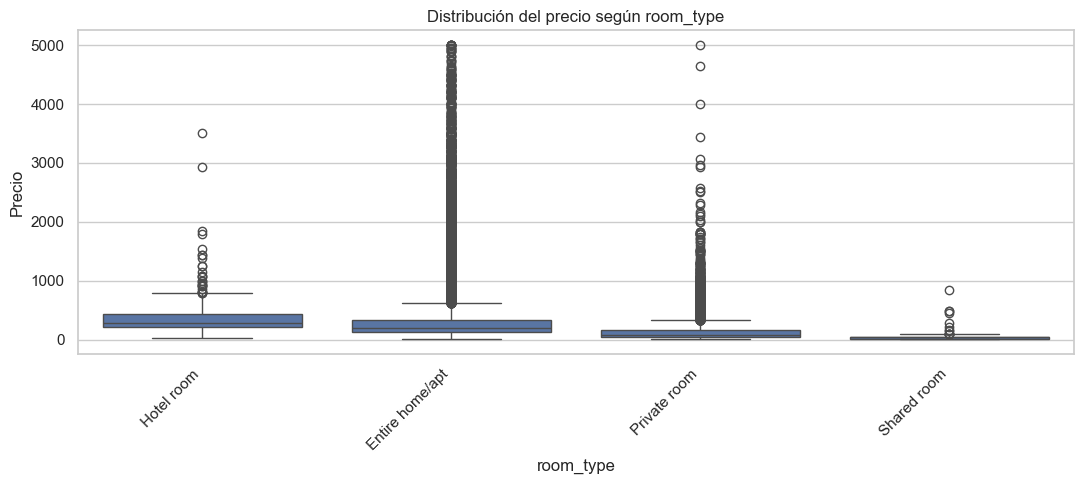

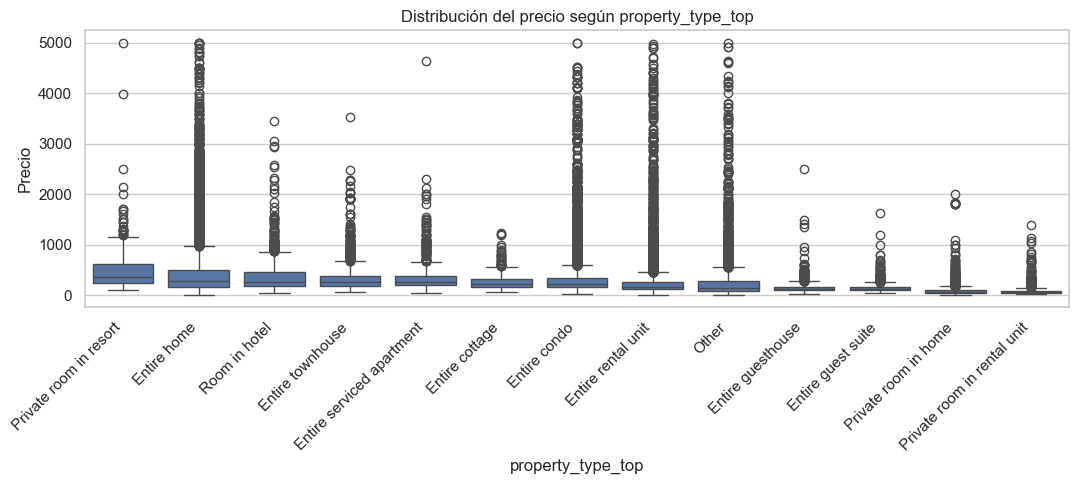

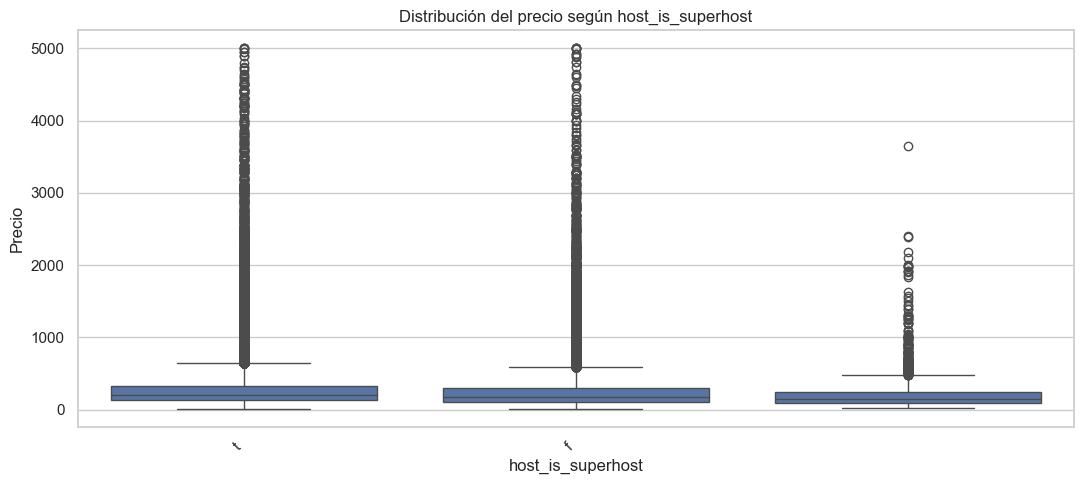

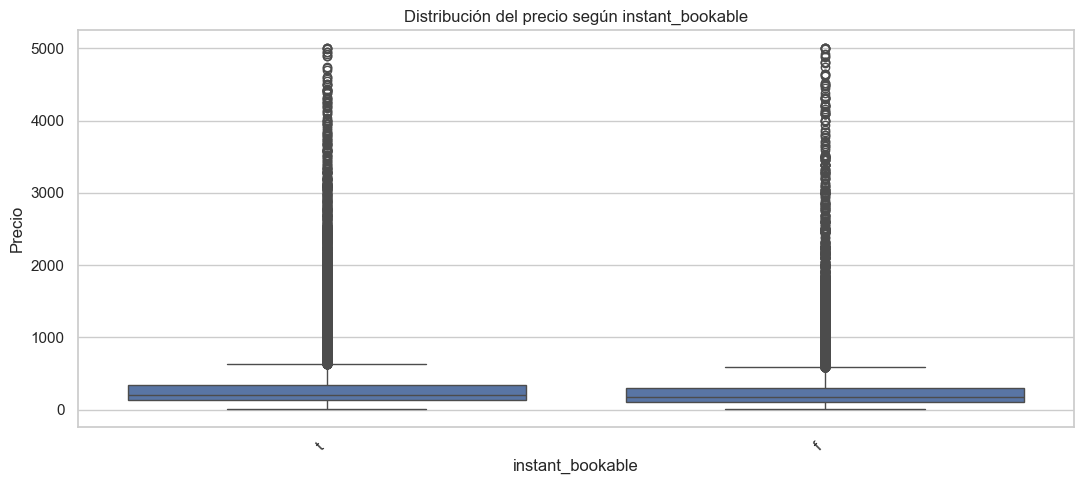

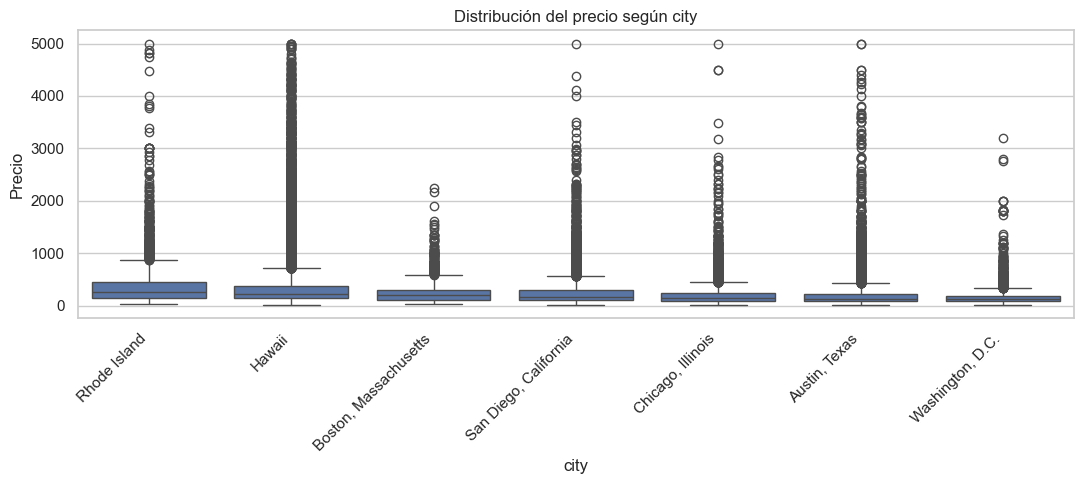

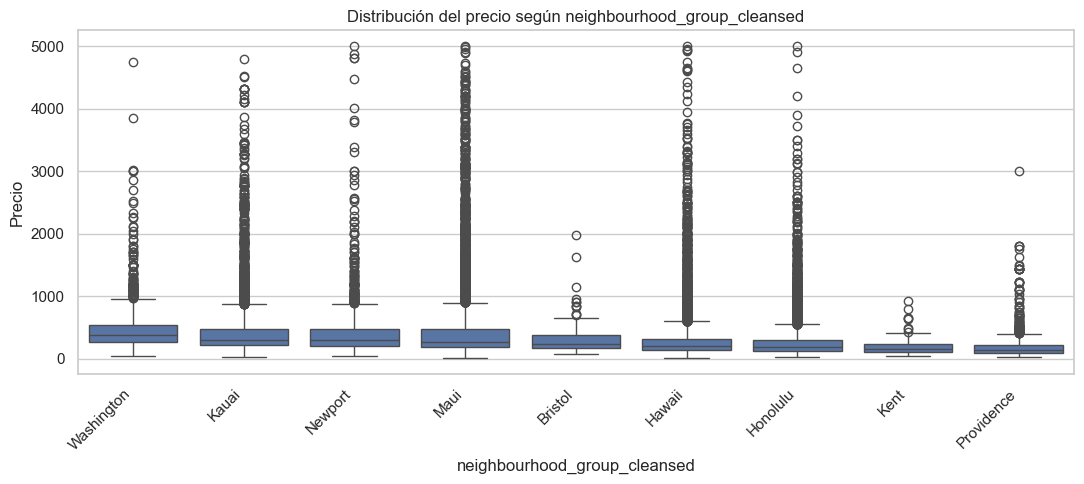

In [26]:
for col in selected_cats:
    plt.figure(figsize=(11, 5))

    order = (
        df_work.groupby(col)["price_clean"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(data=df_work, x=col, y="price_clean", order=order)
    plt.title(f"Distribución del precio según {col}")
    plt.xlabel(col)
    plt.ylabel("Precio")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 7. ANOVA por variable categórica


In [27]:
anova_results = []

for col in selected_cats:
    temp = df_work[[col, "price_clean"]].dropna().copy()
    grupos = [g["price_clean"].values for _, g in temp.groupby(col) if len(g) >= 2]

    if len(grupos) >= 2:
        stat, pvalue = f_oneway(*grupos)
        anova_results.append({
            "variable": col,
            "F": stat,
            "p_value": pvalue
        })

anova_df = pd.DataFrame(anova_results).sort_values("p_value")
anova_df

,variable,F,p_value
0,room_type,517.306328,0.000000e+00
1,property_type_top,455.541092,0.000000e+00
5,neighbourhood_group_cleansed,203.565528,0.000000e+00
4,city,529.117006,0.000000e+00
3,instant_bookable,430.268081,2.632163e-95
2,host_is_superhost,190.601430,2.704931e-83


## 8. Agrupamiento exploratorio


In [28]:
cluster_features = [
    "accommodates",
    "bathrooms",
    "bedrooms_num",
    "beds_num",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365",
    "reviews_per_month"
]

cluster_base = df_work[cluster_features + ["price_clean", "room_type", "city", "host_is_superhost", "instant_bookable", "property_type_top"]].copy()

imputer = SimpleImputer(strategy="median")
X_full = imputer.fit_transform(cluster_base[cluster_features])

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

print("Base para clustering:", cluster_base.shape)

Base para clustering: (75129, 15)


C:\Users\ninan\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\ninan\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 8.1 Elegir k con una muestra


C:\Users\ninan\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


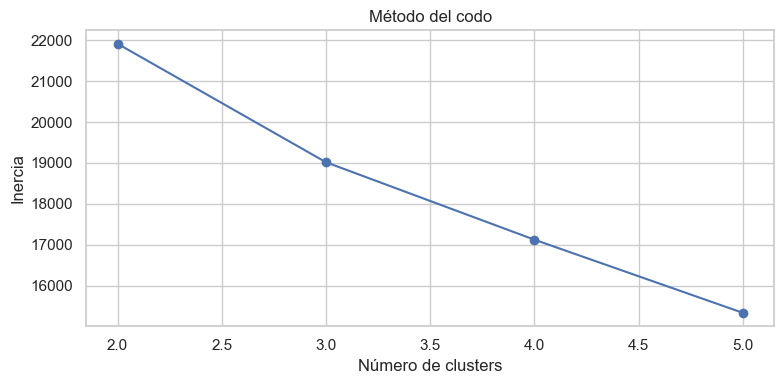

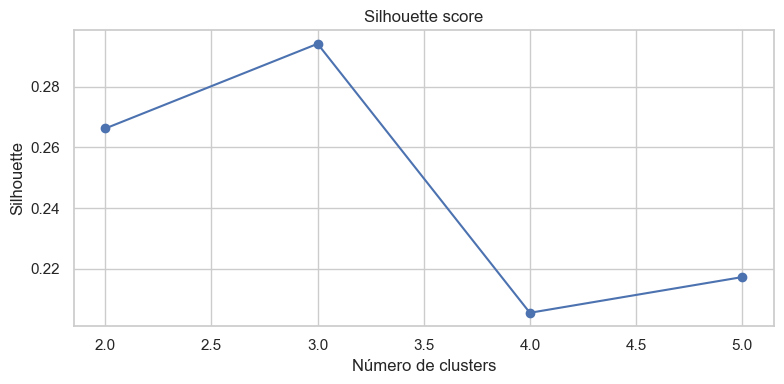

,k,inertia,silhouette
0,2,21913.623957,0.266267
1,3,19015.497719,0.294217
2,4,17121.794849,0.205409
3,5,15333.243177,0.217197


In [29]:
sample_size = min(3000, len(cluster_base))
cluster_sample = cluster_base.sample(n=sample_size, random_state=42).copy()

X_sample = imputer.transform(cluster_sample[cluster_features])
X_sample_scaled = scaler.transform(X_sample)

inertias = []
sil_scores = []
k_values = range(2, 6)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(
        silhouette_score(X_sample_scaled, labels, sample_size=min(1000, len(cluster_sample)), random_state=42)
    )

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": sil_scores
})

### 8.2 Modelo final


In [ ]:
k_final = 3

final_model = MiniBatchKMeans(
    n_clusters=k_final,
    random_state=42,
    batch_size=2048,
    n_init=10
)

cluster_base["cluster"] = final_model.fit_predict(X_full_scaled)
cluster_base["cluster"].value_counts().sort_index()

cluster
0     9633
1    18917
2    46579
Name: count, dtype: int64

## 9. Caracterización de clusters

In [31]:
cluster_summary = (
    cluster_base.groupby("cluster")[cluster_features + ["price_clean"]]
    .mean()
    .round(2)
)

cluster_summary

,accommodates,bathrooms,bedrooms_num,beds_num,minimum_nights,number_of_reviews,review_scores_rating,availability_365,reviews_per_month,price_clean
cluster,,,,,,,,,,
0,3.62,1.17,1.23,1.92,2.70,234.80,4.86,214.67,4.18,159.21
1,8.54,2.67,3.43,4.99,6.57,35.07,4.85,236.59,1.30,553.94
2,3.52,1.26,1.25,1.83,12.15,26.26,4.77,232.92,1.03,221.14


In [32]:
cluster_price_stats = (
    cluster_base.groupby("cluster")["price_clean"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

cluster_price_stats

,count,mean,median,std
cluster,,,,
0,9633,159.21,135.0,102.31
1,18917,553.94,372.0,580.98
2,46579,221.14,166.0,240.64


In [33]:
profile_cats = ["room_type", "city", "host_is_superhost", "instant_bookable", "property_type_top"]

cluster_modes = pd.DataFrame({
    col: cluster_base.groupby("cluster")[col].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    for col in profile_cats
})

cluster_modes

,room_type,city,host_is_superhost,instant_bookable,property_type_top
cluster,,,,,
0,Entire home/apt,Hawaii,t,f,Entire rental unit
1,Entire home/apt,Hawaii,t,f,Entire home
2,Entire home/apt,Hawaii,f,f,Entire rental unit


## 10. Relación grupos-precio

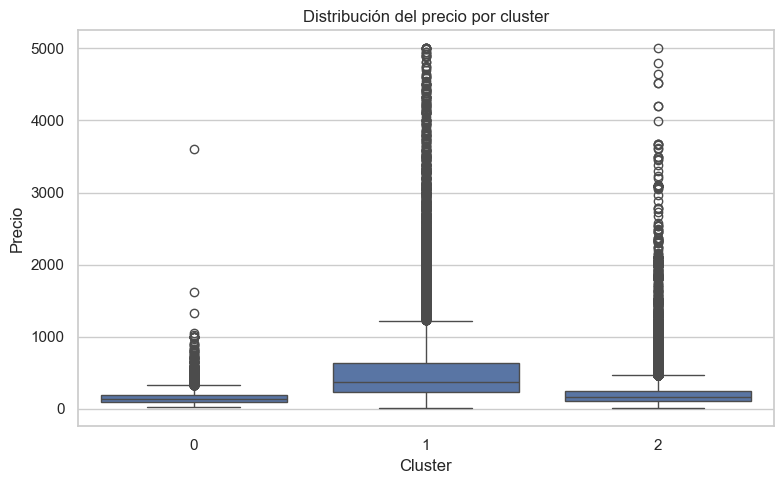

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=cluster_base, x="cluster", y="price_clean")
plt.title("Distribución del precio por cluster")
plt.xlabel("Cluster")
plt.ylabel("Precio")
plt.tight_layout()
plt.show()